In [3]:
import pandas as pd 
import numpy as np

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [5]:
df = pd.read_csv("customer_segmentation.csv")

In [6]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Complain,Age,Total_Children,Total_Spending,Customer_Since,AcceptedAny,AgeGroup,Cluster,PCA1,PCA2
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,68,0,1617,4719,1,60-69,4,1.107519,-0.211760
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,71,2,27,4169,0,70+,1,-1.336734,0.269839
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,60,0,776,4368,0,50-59,4,1.882277,-1.014161
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,41,1,53,4195,0,40-49,0,-1.784359,-0.704928
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,44,1,422,4217,0,40-49,3,0.020363,1.235265


In [7]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4',
       'AcceptedCmp5', 'Response', 'Complain', 'Age', 'Total_Children',
       'Total_Spending', 'Customer_Since', 'AcceptedAny', 'AgeGroup',
       'Cluster', 'PCA1', 'PCA2'],
      dtype='object')

In [8]:
df.shape

(2216, 36)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2216 entries, 0 to 2215
Data columns (total 36 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2216 non-null   int64  
 1   Year_Birth           2216 non-null   int64  
 2   Education            2216 non-null   object 
 3   Marital_Status       2216 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2216 non-null   int64  
 6   Teenhome             2216 non-null   int64  
 7   Dt_Customer          2216 non-null   object 
 8   Recency              2216 non-null   int64  
 9   MntWines             2216 non-null   int64  
 10  MntFruits            2216 non-null   int64  
 11  MntMeatProducts      2216 non-null   int64  
 12  MntFishProducts      2216 non-null   int64  
 13  MntSweetProducts     2216 non-null   int64  
 14  MntGoldProds         2216 non-null   int64  
 15  NumDealsPurchases    2216 non-null   i

In [10]:
df.isna().sum().sum()

np.int64(3)

In [11]:
df.dropna(inplace= True )

In [12]:
df.isna().sum().sum()

np.int64(0)

In [13]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,Response,Complain,Age,Total_Children,Total_Spending,Customer_Since,AcceptedAny,Cluster,PCA1,PCA2
count,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,...,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000
mean,5586.899232,1968.917307,52236.581563,0.441934,0.505648,49.007682,305.153638,26.323995,166.962494,37.635337,...,0.150474,0.009038,56.082693,0.947582,607.021690,4409.731586,0.272933,2.450972,-0.000910,-0.001763
std,3247.819194,11.700216,25178.603047,0.536965,0.544236,28.941864,337.305490,39.735932,224.226178,54.763278,...,0.357617,0.094657,11.700216,0.749297,602.488663,202.450745,0.445567,1.734650,1.741046,1.003786
min,0.000000,1940.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,29.000000,0.000000,5.000000,4056.000000,0.000000,0.000000,-5.125022,-3.256167
25%,2815.000000,1959.000000,35246.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,...,0.000000,0.000000,48.000000,0.000000,69.000000,4236.000000,0.000000,1.000000,-1.621114,-0.794753
50%,5455.000000,1970.000000,51373.000000,0.000000,0.000000,49.000000,175.000000,8.000000,68.000000,12.000000,...,0.000000,0.000000,55.000000,1.000000,397.000000,4412.000000,0.000000,3.000000,-0.148260,-0.020642
75%,8420.000000,1977.000000,68487.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.000000,50.000000,...,0.000000,0.000000,66.000000,1.000000,1048.000000,4585.000000,1.000000,4.000000,1.532060,0.817987
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,1.000000,1.000000,85.000000,3.000000,2525.000000,4755.000000,1.000000,5.000000,10.337382,2.897761


In [14]:
df["Education"].value_counts()

Education
Graduation    1116
PhD            480
Master         365
2n Cycle       198
Basic           54
Name: count, dtype: int64

In [15]:
df["Marital_Status"].value_counts()

Marital_Status
Married     857
Together    572
Single      470
Divorced    231
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

Data cleaning and feature engineering

In [16]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True, errors="coerce")


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2213 entries, 0 to 2215
Data columns (total 36 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2213 non-null   int64         
 1   Year_Birth           2213 non-null   int64         
 2   Education            2213 non-null   object        
 3   Marital_Status       2213 non-null   object        
 4   Income               2213 non-null   float64       
 5   Kidhome              2213 non-null   int64         
 6   Teenhome             2213 non-null   int64         
 7   Dt_Customer          905 non-null    datetime64[ns]
 8   Recency              2213 non-null   int64         
 9   MntWines             2213 non-null   int64         
 10  MntFruits            2213 non-null   int64         
 11  MntMeatProducts      2213 non-null   int64         
 12  MntFishProducts      2213 non-null   int64         
 13  MntSweetProducts     2213 non-null   i

In [18]:
df["Age"] = 2025 - df["Year_Birth"]

In [19]:
df["Age"]

0       68
1       71
2       60
3       41
4       44
        ..
2211    58
2212    79
2213    44
2214    69
2215    71
Name: Age, Length: 2213, dtype: int64

In [20]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Complain,Age,Total_Children,Total_Spending,Customer_Since,AcceptedAny,AgeGroup,Cluster,PCA1,PCA2
0,5524,1957,Graduation,Single,58138.0,0,0,2012-04-09,58,635,...,0,68,0,1617,4719,1,60-69,4,1.107519,-0.211760
1,2174,1954,Graduation,Single,46344.0,1,1,2014-08-03,38,11,...,0,71,2,27,4169,0,70+,1,-1.336734,0.269839
2,4141,1965,Graduation,Together,71613.0,0,0,NaT,26,426,...,0,60,0,776,4368,0,50-59,4,1.882277,-1.014161
3,6182,1984,Graduation,Together,26646.0,1,0,2014-10-02,26,11,...,0,41,1,53,4195,0,40-49,0,-1.784359,-0.704928
4,5324,1981,PhD,Married,58293.0,1,0,NaT,94,173,...,0,44,1,422,4217,0,40-49,3,0.020363,1.235265


In [21]:
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]   

In [22]:
df["Total_Children"]

0       0
1       2
2       0
3       1
4       1
       ..
2211    1
2212    3
2213    0
2214    1
2215    2
Name: Total_Children, Length: 2213, dtype: int64

In [23]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4',
       'AcceptedCmp5', 'Response', 'Complain', 'Age', 'Total_Children',
       'Total_Spending', 'Customer_Since', 'AcceptedAny', 'AgeGroup',
       'Cluster', 'PCA1', 'PCA2'],
      dtype='object')

In [24]:
spend_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

In [25]:
df["Total_Spending"] = df[spend_cols].sum(axis = 1)

In [26]:
df[["Total_Spending"]]

,Total_Spending
0,1617
1,27
2,776
3,53
4,422
...,...
2211,1341
2212,444
2213,1241
2214,843


In [27]:
df["Customer_Since"] = (pd.Timestamp("today") - df["Dt_Customer"]).dt.days

In [28]:
df["Customer_Since"]

0       4917.0
1       4071.0
2          NaN
3       4011.0
4          NaN
         ...  
2211       NaN
2212    4007.0
2213       NaN
2214       NaN
2215       NaN
Name: Customer_Since, Length: 2213, dtype: float64

Data Analysis

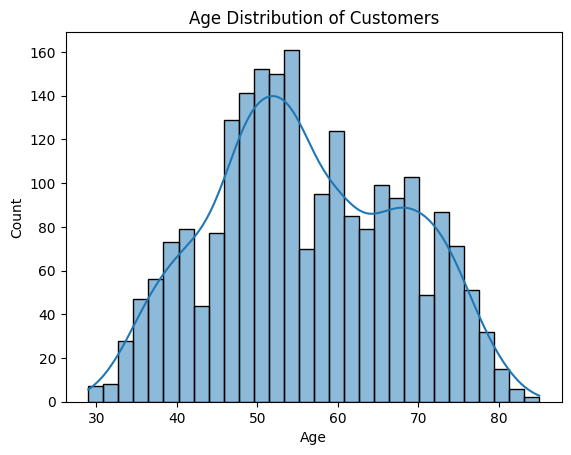

In [29]:
sns.histplot(df["Age"], bins = 30, kde= True)
plt.title("Age Distribution of Customers")
plt.show()

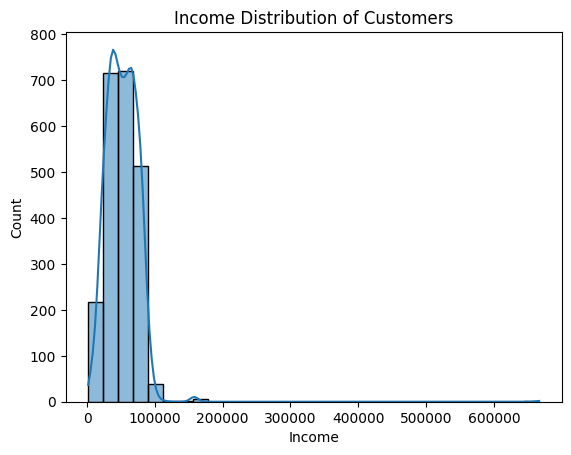

In [30]:
sns.histplot(df["Income"], bins = 30, kde= True)
plt.title("Income Distribution of Customers")
plt.show()

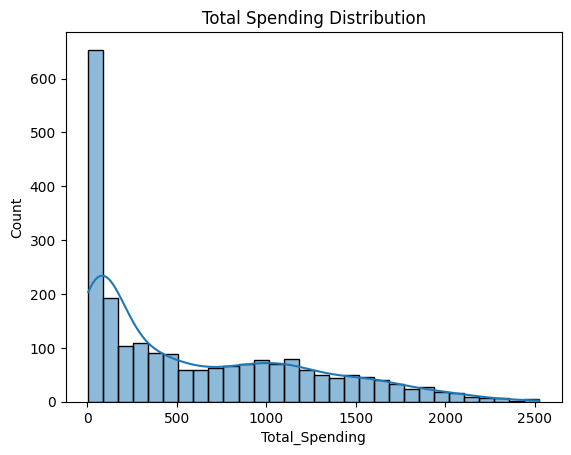

In [31]:
sns.histplot(df["Total_Spending"], bins = 30, kde= True)
plt.title("Total Spending Distribution")
plt.show()

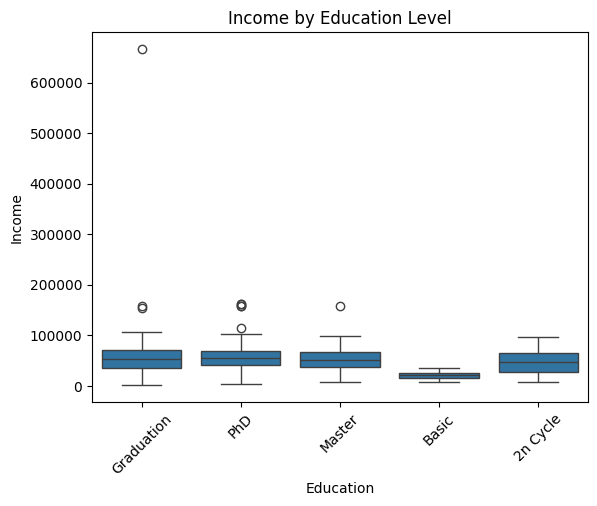

In [32]:
sns.boxplot(x = "Education", y = "Income", data = df)
plt.xticks(rotation=45)
plt.title("Income by Education Level")
plt.show()

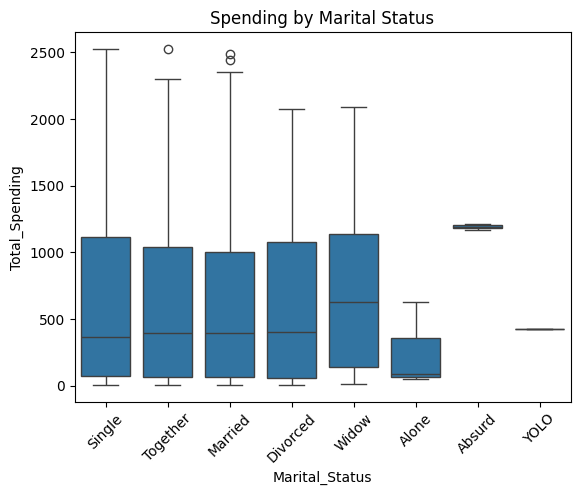

In [33]:
sns.boxplot(x = "Marital_Status", y = "Total_Spending", data = df)
plt.xticks(rotation=45)
plt.title("Spending by Marital Status")
plt.show()

In [34]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4',
       'AcceptedCmp5', 'Response', 'Complain', 'Age', 'Total_Children',
       'Total_Spending', 'Customer_Since', 'AcceptedAny', 'AgeGroup',
       'Cluster', 'PCA1', 'PCA2'],
      dtype='object')

In [35]:
corr = df[["Income", "Age", "Recency", "Total_Spending", "NumWebPurchases","NumStorePurchases"]].corr()

In [36]:
corr

,Income,Age,Recency,Total_Spending,NumWebPurchases,NumStorePurchases
Income,1.000000,0.163295,-0.003111,0.667516,0.388183,0.530120
Age,0.163295,1.000000,0.015971,0.116150,0.162366,0.139229
Recency,-0.003111,0.015971,1.000000,0.020839,-0.005518,-0.000109
Total_Spending,0.667516,0.116150,0.020839,1.000000,0.529141,0.676095
NumWebPurchases,0.388183,0.162366,-0.005518,0.529141,1.000000,0.515805
NumStorePurchases,0.530120,0.139229,-0.000109,0.676095,0.515805,1.000000


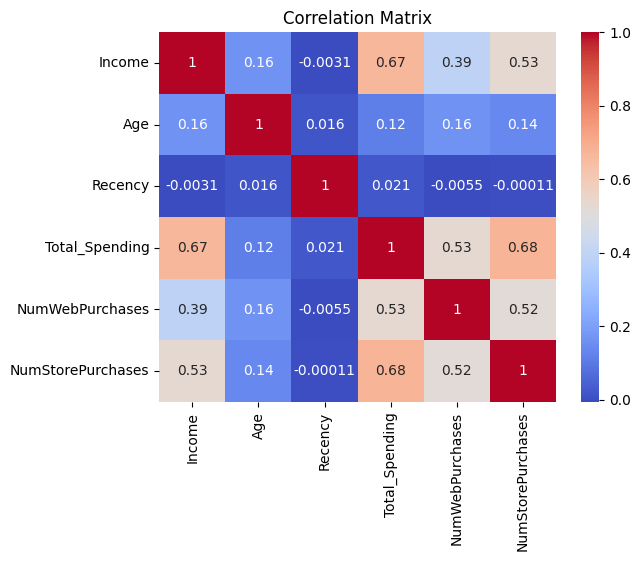

In [37]:
sns.heatmap(corr, annot = True, cmap = "coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [38]:
pivot_income = df.pivot_table(values = "Income", index = "Education", columns = "Marital_Status", aggfunc = "mean" )

In [39]:
pivot_income

Marital_Status,Absurd,Alone,Divorced,Married,Single,Together,Widow,YOLO
Education,,,,,,,,
2n Cycle,NaN,NaN,49974.909091,46201.100000,53488.000000,44736.410714,51392.200000,NaN
Basic,NaN,NaN,9548.000000,21960.500000,18238.666667,21240.071429,22123.000000,NaN
Graduation,79244.0,34176.0,54526.042017,50800.258741,51322.182927,55758.480702,54976.657143,NaN
Master,65487.0,61331.0,50331.945946,53286.028986,53530.560000,52109.009804,58401.545455,NaN
PhD,NaN,35860.0,53096.615385,58138.031579,53314.614583,55802.373913,60288.083333,48432.0


Text(0.5, 1.0, 'Average Income by Education and Marital Status')

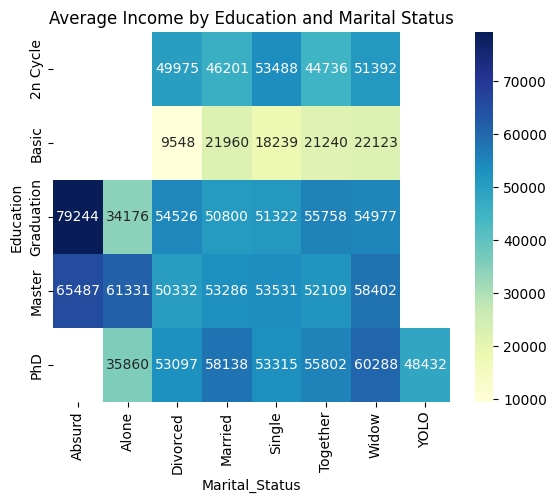

In [40]:
sns.heatmap(pivot_income ,annot = True, fmt = ".0f", cmap = "YlGnBu")
plt.title("Average Income by Education and Marital Status")

In [41]:
group1 = df.groupby("Education")["Total_Spending"].mean().sort_values(ascending= False)

In [42]:
group1

Education
PhD           674.283333
Graduation    621.686380
Master        609.767123
2n Cycle      499.489899
Basic          81.796296
Name: Total_Spending, dtype: float64

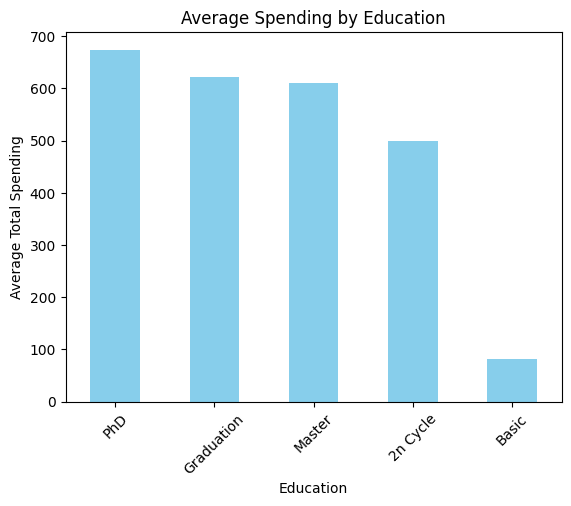

In [43]:
group1.plot(kind= "bar", color = "skyblue")
plt.title("Average Spending by Education")
plt.ylabel("Average Total Spending")
plt.xticks(rotation=45)
plt.show()

In [44]:
df["AcceptedAny"] = df[["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "Response"]].sum(axis=1)

In [45]:
df["AcceptedAny"].unique()

array([1, 0, 3, 2, 4, 5])

In [46]:
df["AcceptedAny"] = df["AcceptedAny"].apply(lambda x: 1 if x > 0 else 0)

In [47]:
df["AcceptedAny"].unique()

array([1, 0])

In [48]:
group2 = df.groupby("Marital_Status")["AcceptedAny"].mean().sort_values(ascending=False)

In [49]:
group2

Marital_Status
Absurd      0.500000
YOLO        0.500000
Widow       0.342105
Alone       0.333333
Single      0.312766
Divorced    0.298701
Married     0.252042
Together    0.250000
Name: AcceptedAny, dtype: float64

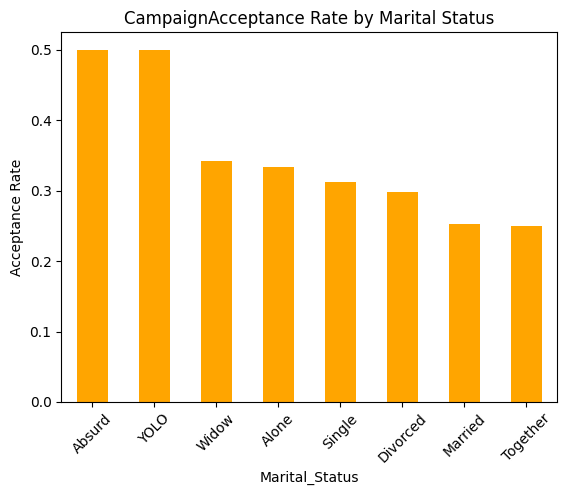

In [50]:
group2.plot(kind = "bar", color = "orange")
plt.title("CampaignAcceptance Rate by Marital Status")
plt.ylabel("Acceptance Rate")
plt.xticks(rotation=45)
plt.show()

In [51]:
bins = [18, 30, 40, 50, 60, 70, 90]

In [52]:
labels = ["18-29", "30-39", "40-49", "50-59", "60-69", "70+"]

In [53]:
df["AgeGroup"] = pd.cut(df["Age"], bins =bins, labels =labels)

In [54]:
df["AgeGroup"]

0       60-69
1         70+
2       50-59
3       40-49
4       40-49
        ...  
2211    50-59
2212      70+
2213    40-49
2214    60-69
2215      70+
Name: AgeGroup, Length: 2213, dtype: category
Categories (6, object): ['18-29' < '30-39' < '40-49' < '50-59' < '60-69' < '70+']

In [55]:
group3 = df.groupby("AgeGroup")["Income"].mean()

/var/folders/9q/mtcdgvh95zlb5bzhvxlh7g9h0000gn/T/ipykernel_95534/1140876350.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group3 = df.groupby("AgeGroup")["Income"].mean()


In [56]:
group3

AgeGroup
18-29    46658.000000
30-39    46283.028302
40-49    49224.877034
50-59    50812.913303
60-69    56200.827887
70+      58944.316294
Name: Income, dtype: float64

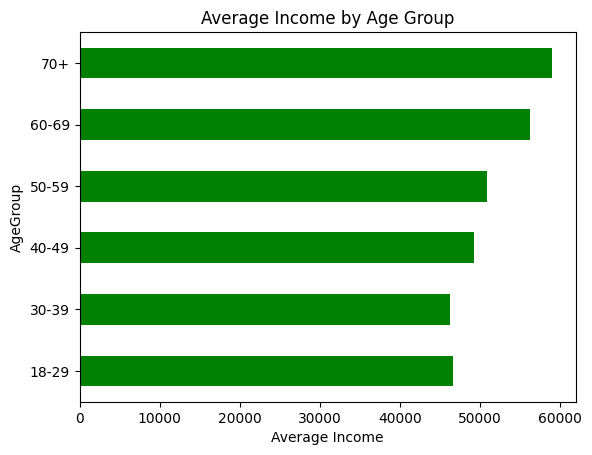

In [57]:
group3.plot(kind = "barh", color= "green")
plt.title("Average Income by Age Group")
plt.xlabel("Average Income")
plt.show()

In [58]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Complain,Age,Total_Children,Total_Spending,Customer_Since,AcceptedAny,AgeGroup,Cluster,PCA1,PCA2
0,5524,1957,Graduation,Single,58138.0,0,0,2012-04-09,58,635,...,0,68,0,1617,4917.0,1,60-69,4,1.107519,-0.211760
1,2174,1954,Graduation,Single,46344.0,1,1,2014-08-03,38,11,...,0,71,2,27,4071.0,0,70+,1,-1.336734,0.269839
2,4141,1965,Graduation,Together,71613.0,0,0,NaT,26,426,...,0,60,0,776,NaN,0,50-59,4,1.882277,-1.014161
3,6182,1984,Graduation,Together,26646.0,1,0,2014-10-02,26,11,...,0,41,1,53,4011.0,0,40-49,0,-1.784359,-0.704928
4,5324,1981,PhD,Married,58293.0,1,0,NaT,94,173,...,0,44,1,422,NaN,0,40-49,3,0.020363,1.235265


In [59]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4',
       'AcceptedCmp5', 'Response', 'Complain', 'Age', 'Total_Children',
       'Total_Spending', 'Customer_Since', 'AcceptedAny', 'AgeGroup',
       'Cluster', 'PCA1', 'PCA2'],
      dtype='object')

Demografik veriler

In [60]:
features = ["Age", "Income", "Total_Spending", "NumWebPurchases", "NumStorePurchases","NumWebVisitsMonth","Recency"  ]

In [61]:
X = df[features].copy()

In [62]:
X

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
0,68,58138.0,1617,8,4,7,58
1,71,46344.0,27,1,2,5,38
2,60,71613.0,776,8,10,4,26
3,41,26646.0,53,2,4,6,26
4,44,58293.0,422,5,6,5,94
...,...,...,...,...,...,...,...
2211,58,61223.0,1341,9,4,5,46
2212,79,64014.0,444,8,5,7,56
2213,44,56981.0,1241,2,13,6,91
2214,69,69245.0,843,6,10,3,8


In [70]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [71]:
X_scaled = scaler.fit_transform(X)

In [72]:
X_scaled

array([[ 1.01878463,  0.23443526,  1.67672297, ..., -0.55545607,
         0.69219825,  0.31077302],
       [ 1.2752481 , -0.23408421, -0.9629273 , ..., -1.17083744,
        -0.13269929, -0.38042366],
       [ 0.33488204,  0.76973285,  0.28053059, ...,  1.29068803,
        -0.54514805, -0.79514166],
       ...,
       [-1.03292314,  0.18847315,  1.05250378, ...,  2.21376009,
         0.27974948,  1.45124754],
       [ 1.10427245,  0.67566348,  0.39176114, ...,  1.29068803,
        -0.95759682, -1.41721867],
       [ 1.2752481 ,  0.02512297, -0.72220448, ..., -0.55545607,
         0.69219825, -0.31130399]], shape=(2213, 7))

K-means for clustering. We need to a k for grouping number

In [73]:
from sklearn.cluster import KMeans

In [74]:
wcss = []

In [75]:
for i in range(2, 10):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

In [76]:
wcss

[10197.938709834989,
 8985.016964594543,
 8778.147937476733,
 7622.343498407213,
 7056.425594144128,
 6673.8811344639125,
 6221.188421338005,
 5860.218733234589]

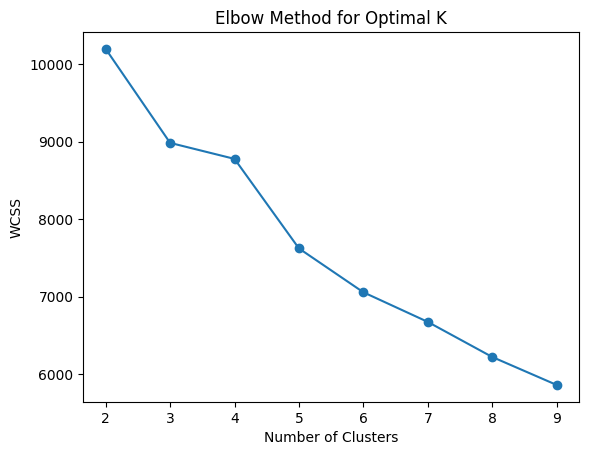

In [77]:
plt.plot(range(2, 10), wcss, marker = "o")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [78]:
kmeans = KMeans(n_clusters = 6)
df["Cluster"] = kmeans.fit_predict(X_scaled)

In [79]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Complain,Age,Total_Children,Total_Spending,Customer_Since,AcceptedAny,AgeGroup,Cluster,PCA1,PCA2
0,5524,1957,Graduation,Single,58138.0,0,0,2012-04-09,58,635,...,0,68,0,1617,4917.0,1,60-69,0,1.107519,-0.211760
1,2174,1954,Graduation,Single,46344.0,1,1,2014-08-03,38,11,...,0,71,2,27,4071.0,0,70+,5,-1.336734,0.269839
2,4141,1965,Graduation,Together,71613.0,0,0,NaT,26,426,...,0,60,0,776,NaN,0,50-59,0,1.882277,-1.014161
3,6182,1984,Graduation,Together,26646.0,1,0,2014-10-02,26,11,...,0,41,1,53,4011.0,0,40-49,5,-1.784359,-0.704928
4,5324,1981,PhD,Married,58293.0,1,0,NaT,94,173,...,0,44,1,422,NaN,0,40-49,1,0.020363,1.235265


In [80]:
cluster_summary = df.groupby("Cluster")[features].mean()


In [81]:
cluster_summary

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
Cluster,,,,,,,
0,58.240283,62085.618375,1039.236749,8.388693,8.643110,6.204947,61.554770
1,55.407186,36719.672655,128.696607,2.363273,3.445110,6.359281,76.393214
2,45.934375,78637.218750,1307.153125,4.612500,8.603125,2.681250,47.296875
3,62.561224,54035.037415,574.336735,5.843537,6.380952,6.272109,25.272109
4,69.060000,74084.656667,1185.200000,4.426667,8.363333,2.383333,54.270000
5,50.601942,31761.477670,81.658252,1.875728,2.984466,6.636893,27.019417


In [82]:
df["Cluster"].value_counts()

Cluster
5    515
1    501
2    320
4    300
3    294
0    283
Name: count, dtype: int64

In [83]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)
df["PCA1"], df["PCA2"] = pca_data[:,0], pca_data[:,1]


In [84]:
pca_data

array([[ 1.11634966, -0.46388922],
       [-1.32625816,  0.13850704],
       [ 1.88488388, -1.05323789],
       ...,
       [ 1.14772108,  1.31312895],
       [ 1.89562258, -1.22785534],
       [-0.83074255, -0.36944049]], shape=(2213, 2))

In [85]:
df["PCA1"]

0       1.116350
1      -1.326258
2       1.884884
3      -1.793038
4       0.013986
          ...   
2211    1.249624
2212    0.525242
2213    1.147721
2214    1.895623
2215   -0.830743
Name: PCA1, Length: 2213, dtype: float64

In [86]:
df["PCA2"]

0      -0.463889
1       0.138507
2      -1.053238
3      -0.495944
4       1.325090
          ...   
2211   -0.622176
2212   -0.556131
2213    1.313129
2214   -1.227855
2215   -0.369440
Name: PCA2, Length: 2213, dtype: float64

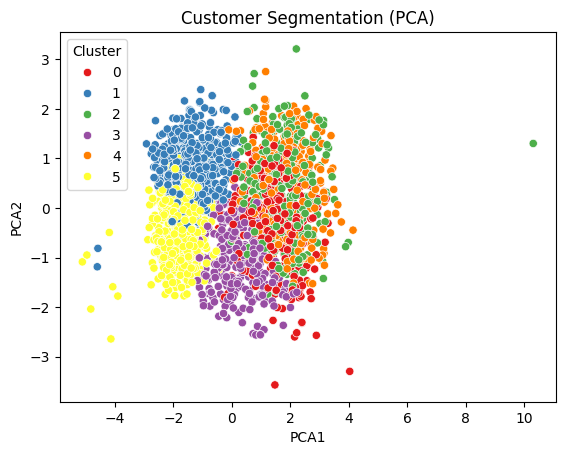

In [87]:
sns.scatterplot(x= "PCA1", y="PCA2", hue = "Cluster", data = df, palette = "Set1" )
plt.title("Customer Segmentation (PCA)")
plt.show()

In [88]:
cluster_summary

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
Cluster,,,,,,,
0,58.240283,62085.618375,1039.236749,8.388693,8.643110,6.204947,61.554770
1,55.407186,36719.672655,128.696607,2.363273,3.445110,6.359281,76.393214
2,45.934375,78637.218750,1307.153125,4.612500,8.603125,2.681250,47.296875
3,62.561224,54035.037415,574.336735,5.843537,6.380952,6.272109,25.272109
4,69.060000,74084.656667,1185.200000,4.426667,8.363333,2.383333,54.270000
5,50.601942,31761.477670,81.658252,1.875728,2.984466,6.636893,27.019417


In [89]:
import joblib 

joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [94]:
# PowerBI için temizlenmiş veriyi export et
df_powerbi = df.copy()

# PowerBI için gerekli tüm sütunları hazırla
powerbi_columns = [
    'ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 
    'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency',
    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 
    'MntSweetProducts', 'MntGoldProds',
    'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 
    'NumStorePurchases', 'NumWebVisitsMonth',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 
    'AcceptedCmp5', 'Response', 'Complain',
    'Age', 'Total_Children', 'Total_Spending', 'Customer_Since',
    'AcceptedAny', 'AgeGroup', 'Cluster', 'PCA1', 'PCA2'
]

# Sadece gerekli sütunları seç
df_powerbi = df_powerbi[powerbi_columns]

# CSV olarak export et
df_powerbi.to_csv("customer_segmentation_for_powerbi.csv", index=False)

print("✅ Temizlenmiş veri PowerBI için export edildi!")
print(f"📊 Toplam müşteri sayısı: {len(df_powerbi)}")
print(f"📈 Toplam sütun sayısı: {len(df_powerbi.columns)}")
print(f"🎯 Segment sayısı: {df_powerbi['Cluster'].nunique()}")


✅ Temizlenmiş veri PowerBI için export edildi!
📊 Toplam müşteri sayısı: 2213
📈 Toplam sütun sayısı: 36
🎯 Segment sayısı: 6


In [95]:
# PowerBI dashboard için özet istatistikler
print("=== PowerBI Dashboard İçin Özet İstatistikler ===")
print("\n📊 Segment Dağılımı:")
print(df_powerbi['Cluster'].value_counts().sort_index())

print("\n💰 Segment Bazında Ortalama Değerler:")
segment_summary = df_powerbi.groupby('Cluster').agg({
    'Age': 'mean',
    'Income': 'mean', 
    'Total_Spending': 'mean',
    'NumWebPurchases': 'mean',
    'NumStorePurchases': 'mean',
    'AcceptedAny': 'mean'
}).round(2)

print(segment_summary)

print("\n🎯 Kampanya Kabul Oranları:")
campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']
campaign_rates = df_powerbi[campaign_cols].mean() * 100
print(campaign_rates.round(2))


=== PowerBI Dashboard İçin Özet İstatistikler ===

📊 Segment Dağılımı:
Cluster
0    302
1    522
2    364
3    541
4    483
5      1
Name: count, dtype: int64

💰 Segment Bazında Ortalama Değerler:
           Age     Income  Total_Spending  NumWebPurchases  NumStorePurchases  \
Cluster                                                                         
0        56.89   62254.67         1025.40             7.82               8.80   
1        56.00   37279.33          136.96             2.45               3.52   
2        63.57   59357.46          721.59             6.20               7.43   
3        50.80   32248.97           92.75             2.00               3.05   
4        55.95   77886.87         1344.26             4.27               8.27   
5        48.00  666666.00           62.00             3.00               3.00   

         AcceptedAny  
Cluster               
0               0.32  
1               0.11  
2               0.32  
3               0.19  
4               

In [98]:
# Segment isimlendirme önerileri PowerBI için
segment_names = {
    0: "Economy Customers",
    1: "High Value Customers", 
    2: "Mid-Range Customers",
    3: "Digital Active Customers",
    4: "Store-Focused Customers",
    5: "Potential Customers"
}

# Segment isimlerini DataFrame'e ekle
df_powerbi['Segment_Name'] = df_powerbi['Cluster'].map(segment_names)

# Güncellenmiş dosyayı tekrar kaydet
df_powerbi.to_csv("customer_segmentation_for_powerbi.csv", index=False)

print("✅ Segment names added and file updated!")
print("\n🏷️ Segment Names:")
for cluster, name in segment_names.items():
    count = len(df_powerbi[df_powerbi['Cluster'] == cluster])
    percentage = (count / len(df_powerbi)) * 100
    print(f"Segment {cluster}: {name} ({count} customer, %{percentage:.1f})")


✅ Segment names added and file updated!

🏷️ Segment Names:
Segment 0: Economy Customers (302 customer, %13.6)
Segment 1: High Value Customers (522 customer, %23.6)
Segment 2: Mid-Range Customers (364 customer, %16.4)
Segment 3: Digital Active Customers (541 customer, %24.4)
Segment 4: Store-Focused Customers (483 customer, %21.8)
Segment 5: Potential Customers (1 customer, %0.0)
